<a href="https://colab.research.google.com/github/jjoo0727/Convective-Systems-Tropical-Dynamics-Laboratory/blob/main/ClimDetect_Demo_ModelTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Example: Training a Vision Transformer on ClimDetect

This notebook demonstrates how to train a Vision Transformer model on the [ClimDetect](https://huggingface.co/datasets/ClimDetect/ClimDetect) dataset for climate change detection and attribution tasks. While we use [`ViT-b/16`](https://huggingface.co/google/vit-base-patch16-224-in21k) as the example architecture, the same workflow can be adapted to other models.


In [2]:
hf_model = 'google/vit-base-patch16-224-in21k' # "openai/clip-vit-base-patch16", "facebook/vit-mae-base"

## [1] Load ClimDetect Dataset

We load the ClimDetect dataset from the Hugging Face Hub using the `datasets` library.  

You can select from one of the following subsets:
- `'default'`: Full dataset
- `'mini'`: Small development subset (faster to load/run)
- `'reanalysis'`: Dataset based on observational reanalysis data

📌 Note: In this notebook, we use the `'mini'` subset for quick demonstration. You can switch to `'default'` for full training or `'reanalysis'` for evaluation on real-world data.


In [3]:
# ⚠️ Install Hugging Face `datasets` library (not preinstalled in Colab)
!pip install -U datasets

In [4]:
from datasets import load_dataset
subset = 'mini' # Choices: 'default', 'mini', 'reanalysis'
dataset = load_dataset("ClimDetect/ClimDetect",
                       subset
                       )


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/146 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/26 [00:00<?, ?it/s]

...

mini/test/GFDL-CM4_gr1_historical-1850-1(…):   0%|          | 0.00/125M [00:00<?, ?B/s]

mini/test/GFDL-CM4_gr1_historical-1950-2(…):   0%|          | 0.00/81.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14986 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/4244 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/4244 [00:00<?, ? examples/s]

## [Bonus Section] Inspect and Visualize a Sample Input

Before training, it’s helpful to inspect the structure and content of individual dataset samples.

**Input**: A single training sample includes three input variables:

- `'tas'`: 2-meter surface air temperature  
- `'huss'`: 2-meter specific humidity  
- `'pr'`: total precipitation  

Each variable is stored as a 2D global map (latitude × longitude), and together they form a 3-channel input tensor — analogous to an RGB image, but with physically meaningful climate variables instead of color channels.

**Target**: The target label is a scalar floating-point number representing the annual global mean temperature (AGMT) anomaly for the input snapshot.

**Shortly**: T2M, q2M, pr -> scalar floating-point number representing the annual global mean temperature (AGMT)


In [10]:
# One training sample
print(dataset['train'][0])

{'input': [[[0.4605693519115448, 0.44679898023605347, 0.42591023445129395, 0.4031779170036316, 0.3674980700016022, 0.3067677915096283, 0.1829410195350647, 0.08262662589550018, 0.009863094426691532, -0.041120849549770355, 0.0032762789633125067, -0.04323950037360191, -0.1227387860417366, -0.26443636417388916, -0.4510255455970764, -0.48774901032447815, -0.48605820536613464, -0.486945241689682, -0.4884141683578491, -0.4881753623485565, -0.4960205554962158, -0.5032910704612732, -0.5095592737197876, -0.5158891677856445, -0.5211711525917053, -0.525038480758667, -0.52761310338974, -0.5290204286575317, -0.5274732112884521, -0.5218121409416199, -0.5151804089546204, -0.5086525678634644, -0.5003368854522705, -0.4936352074146271, -0.48667240142822266, -0.479655385017395, -0.47260981798171997, -0.46532386541366577, -0.4582465887069702, -0.4510990381240845, -0.4408532977104187, -0.4254274368286133, -0.4087781310081482, -0.38714599609375, -0.36306431889533997, -0.32777726650238037, -0.2888364195823669

Input shape (channel, latitude, longitude):  (3, 64, 128)
Target (AGMT):  -0.7233045697212219


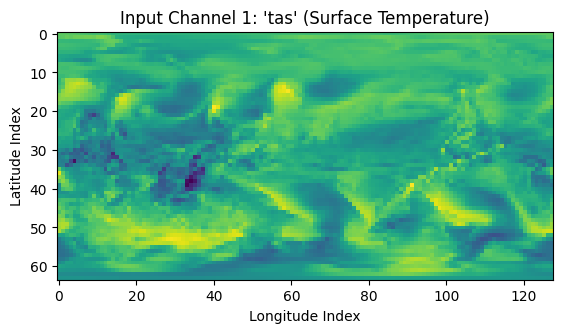

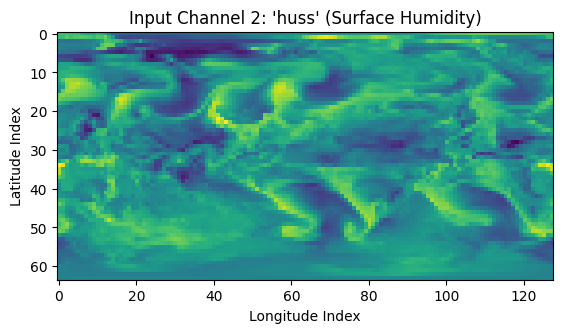

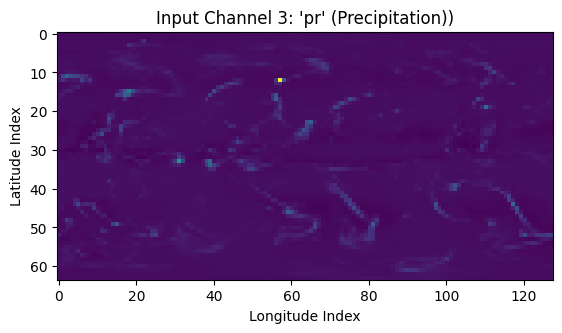

In [11]:
# Input snapshot visualization
import numpy as np
import matplotlib.pyplot as plt

# Pick the first sample
sample = np.array(dataset['train'][0]['input']) # shape: (3, 64, 128)
                                                #        (channel, latitutde, longitude)
print("Input shape (channel, latitude, longitude): ", sample.shape)

# plot the first channel (surface temperature)
fig , ax = plt.subplots()
ax.imshow(sample[0,:,:])
ax.set_title("Input Channel 1: 'tas' (Surface Temperature)")
ax.set_xlabel("Longitude Index")
ax.set_ylabel("Latitude Index")


# plot the second channel (surface humidity)
fig , ax = plt.subplots()
ax.imshow(sample[1,:,:])
ax.set_title("Input Channel 2: 'huss' (Surface Humidity)")
ax.set_xlabel("Longitude Index")
ax.set_ylabel("Latitude Index")


# plot the third channel (precipitation)
fig , ax = plt.subplots()
ax.imshow(sample[2,:,:])
ax.set_title("Input Channel 3: 'pr' (Precipitation))")
ax.set_xlabel("Longitude Index")
ax.set_ylabel("Latitude Index")


# Target value
print('Target (AGMT): ', dataset['train'][0]['target'])

## [2] Convert to PyTorch Dataset
The dataset can be wrapped into a standard PyTorch Dataset class for model training.


### [2.a] Defining Experiment-specific Input :Transformations

We define two custom transformations for experimental variations. They are **only used in specific experiments** and are not required for standard 3-variable expeirments (e.g., `"tas-huss-pr"`). Use them if you wish to replicate the `"*_only"` or `"*_mr"` experimental setups:


- **`Convert_to_1var`**: Enables single-variable experiments (e.g., `"tas_only"`, `"huss_only"`, `"pr_only"`). This transformation replaces all three channels with the values from a specified variable, effectively creating a dataset where only one variable is present across all channels.

- **`Remove_mean`**: Enables mean-removed experiments (e.g., `"tas-huss-pr_mr"`, `"tas_mr"`). This transformation subtracts the area-weighted spatial average from each variable (channel) using cosine-latitude weights. This is useful for experiments focusing on spatial patterns rather than absolute mean values.


In [12]:
import torch

class Convert_to_1var(torch.nn.Module):
    def __init__(self, climvar='tas'):
        super(Convert_to_1var, self).__init__()
        self.climvar = climvar
    def forward(self, image):
        if self.climvar=='tas':
            image[1,:,:] = image[0,:,:]
            image[2,:,:] = image[0,:,:]
        elif self.climvar=='huss':
            image[0,:,:] = image[1,:,:]
            image[2,:,:] = image[1,:,:]
        elif self.climvar=='pr':
            image[0,:,:] = image[2,:,:]
            image[1,:,:] = image[2,:,:]
        return image

# Callibrate with mean and std
class Remove_mean(torch.nn.Module):
    def __init__(self):
        super(Remove_mean, self).__init__()
        self.lat = torch.tensor([-88.59375, -85.78125, -82.96875, -80.15625, -77.34375, -74.53125,
                                 -71.71875, -68.90625, -66.09375, -63.28125, -60.46875, -57.65625,
                                 -54.84375, -52.03125, -49.21875, -46.40625, -43.59375, -40.78125,
                                 -37.96875, -35.15625, -32.34375, -29.53125, -26.71875, -23.90625,
                                 -21.09375, -18.28125, -15.46875, -12.65625, -9.84375, -7.03125, -4.21875,
                                 -1.40625, 1.40625, 4.21875, 7.03125, 9.84375, 12.65625, 15.46875,
                                 18.28125, 21.09375, 23.90625, 26.71875, 29.53125, 32.34375, 35.15625,
                                 37.96875, 40.78125, 43.59375, 46.40625, 49.21875, 52.03125, 54.84375,
                                 57.65625, 60.46875, 63.28125, 66.09375, 68.90625, 71.71875, 74.53125,
                                 77.34375, 80.15625, 82.96875, 85.78125, 88.59375
                                 ])
        self.coslat = torch.cos(torch.deg2rad(self.lat))
        self.wgt2d = self.coslat.repeat(128, 1).transpose(0,1)
        self.wgt2d = self.wgt2d / self.wgt2d.sum()

    def forward(self, image):
        for k in range(3):
            image[k,:,:] = image[k,:,:] - (image[k,:,:] * self.wgt2d).sum()
        return image



### [2.b] Defining Model-Specific Input Transformation Parameters

To ensure compatibility, we extract the required normalization statistics and input image size using the model’s processor. Here, we use `ViTImageProcessor` associated with the `ViT-b/16` model.

Note: If you are using a different vision model, you may need to use a different processor class such as `AutoImageProcessor`.


In [13]:
from transformers import ViTImageProcessor

# Load ViT image processor (for normalization and resizing transformations)
processor = ViTImageProcessor.from_pretrained(hf_model)

# Get transformation parameters and input size
image_mean, image_std = processor.image_mean, processor.image_std
size = processor.size["height"] # ViT/b-16 uses square inputs: height == width

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

### [2.c] Assembling the Final Input Transformation Pipeline

In [14]:
from torchvision.transforms import Compose, Normalize, Resize

# Normalize dataset into _dataset_transforms
_dataset_transforms = Compose([
    # ⚠️ Uncomment the following lines for specific experiment settings:
    # Remove_mean(),                    # Use for mean-removed (mr) experiments
    # Convert_to_1var(climvar='tas'),   # Use for single-variable experiments. Choices: ['tas', 'huss', 'pr']
    Resize([size, size]),
    Normalize(mean=image_mean, std=image_std),
])


### [2.d] Convert to Pytorch Dataset
We wrap the Hugging Face `Dataset` objects into PyTorch-compatible datasets, applying the defined input transformation during retrieval.


In [15]:
from torch.utils.data import Dataset

#Bring hugging face dataset as self.ds
class CMIPDataSet(Dataset):
  def __init__(self, hfdataset, transform=None):
      self.ds = hfdataset
      self.transform = transform

  def __len__(self):
      return self.ds.num_rows

  def __getitem__(self, idx):
      input = self.ds[idx]['input']
      target = self.ds[idx]['target']
      if self.transform:
          input = self.transform(input)
      return {'pixel_values': input, 'labels': target}

# PyTorch's Dataset instances
train_ds = CMIPDataSet(dataset['train'].with_format("torch"), transform=_dataset_transforms)
val_ds = CMIPDataSet(dataset['validation'].with_format("torch"), transform=_dataset_transforms)
test_ds = CMIPDataSet(dataset['test'].with_format("torch"), transform=_dataset_transforms)

## [3] Model Training

In this section, we train the model on the ClimDetect dataset using the ViT architecture.  
Note that the training configuration (e.g., batch size, learning rate, number of epochs) is set for quick demonstration purposes.

⚠️ Due to resource limitations on the Colab free tier, these settings do not replicate the full training setup used in the original study or benchmark experiments.


### [3.a] Check if CUDA Devices Are Available

In [16]:
# Runtime type: Hardware accelerate = "T4 GPU"
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Number of CUDA devices:", )
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")

CUDA available: True
Number of CUDA devices:
Device 0: Tesla T4


### [3.b] Instantiating a Model

In [17]:
from transformers import ViTForImageClassificati

# hf_model: 'google/vit-base-patch16-224-in21k' (pretrained with image-net)
config = ViTConfig.from_pretrained(hf_model)
config.num_labels = 1
config.problem_type = 'regression'
model = ViTForImageClassification(config)

config.json:   0%|          | 0.00/502 [00:00<?, ?B/s]

### [3.c] Configuring Training Parameters

In [18]:
import os
from transformers import TrainingArguments, Trainer

os.makedirs("ckpt", exist_ok=True)
args = TrainingArguments(learning_rate=5e-4,
                         per_device_train_batch_size=64,
                         per_device_eval_batch_size=128,
                         num_train_epochs=1,
                         fp16=True,
                         output_dir='./ckpt',
                         overwrite_output_dir=True,
                         load_best_model_at_end=True,
                         eval_strategy="steps",
                         save_strategy="steps",
                         save_steps = 30,
                         logging_steps = 30,
                         report_to=[],
                        )

trainer = Trainer(
                    model,
                    args,
                    train_dataset=train_ds,
                    eval_dataset=val_ds,
                    # compute_metrics=compute_metrics
                )

### [3.d] Training the Model

In [19]:
trainer.train()

Step,Training Loss,Validation Loss
30,8.941200,0.697812
60,0.293200,0.398158
90,0.321000,0.184678
120,0.190800,0.051175
150,0.098900,0.258244
180,0.116000,0.064693
210,0.051800,0.041382


TrainOutput(global_step=235, training_loss=1.2826034297334388, metrics={'train_runtime': 480.6691, 'train_samples_per_second': 31.177, 'train_steps_per_second': 0.489, 'total_flos': 1.1612845480449024e+18, 'train_loss': 1.2826034297334388, 'epoch': 1.0})

## [4] Evaluation on the Test Set

After training, we assess model performance on the held-out test set using RMSE.


### [4.a] Inference on the held-out test set

In [20]:
trainer.model.eval()
output = trainer.predict(test_ds)
y_pred = output.predictions.squeeze()
y_true = output.label_ids.squeeze()
test_rmse = np.sqrt(np.mean((y_pred - y_true)**2.))

### [4.b] Test RMSE

In [22]:
RMSE = np.sqrt(np.mean((y_pred - y_true)**2.))
print(f"Test RMSE: {RMSE.item():.4f} [unit: °C]")

Test RMSE: 0.1755 [unit: °C]


In [26]:
output.predictions.shape

(4244, 1)